# Using RAiDER to correct InSAR time-series

**Author**: Jeremy Maurer

This notebook provides an overview of how to use RAiDER to calculate troposphere time-series for use correcting InSAR observations, using standard displacement products from [OPERA](https://www.jpl.nasa.gov/go/opera/). 
We give an example of how to download and process delays using the ERA-5 weather model for the Los Angeles region. 

In this notebook, we will demonstrate how to use the raider.py command-line utility to download and process a series of tropospheric delays for use in correcting InSAR time-series. 

The notebook will take approximately 15 minutes to run all the way through aside from the data download step. 

<div class="alert alert-danger">
<b>Potential Errors:</b> 
    
- RAiDER needs to be installed to run this notebook  
</div>


<div class="alert alert-info">
    <b>Terminology:</b>
    
- *Acquisition*: A single image acquired by a satellite at a particular time
- *AOI*: Area of interest: the lat/lon area (in RAiDER a square region) containing your query points
- *Interferogram*: An unwrapped image containing the surface displacement accumulated between two acquisitions.
- *SLC*: Single-look complex image. A complex single-band raster that contains a single focused RADAR frame from a SAR satellite. For Sentinel-1, SLCs are Level-1 products. 
- *Weather model*: A reanalysis weather product defining temperature, pressure, and humidity on a regular grid in some coordinate system (e.g., at regular lat/lon intervals in the standard EPSG:4326 reference frame).
- *Delay*: The apparent displacement in an interferogram that occurs solely due to changes in weather conditions between two acquisitions.</div>
    

## Table of Contents

[**Example Calculations**](#examples)  
[1. Downloading the weather model data using geometry information from interferograms](#bounding_box_example)  
[2. Compute Zenith total delay at interferogram pixels](#bounding_box_ztd)  
[3. Compute Slant total delay at interferogram pixels](#station_list_example)  
[4. Visualizing Delays](#station_list_visualization)  
[5. Compute corrected time-series](#raster_example)  

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

In [4]:
# Verifying if RAiDER is installed correctly
try:
    import RAiDER
except:
    raise Exception('RAiDER is missing from your PYTHONPATH')

## Access InSAR time-series from OPERA

For this exercise we will use data from the OPERA project, which provides pre-processed time-series we can use. 
A small subset of the time-series available for an ascending track covering Los Angeles is included with this repository for demonstration purposes. 
We can load and plot the time-series using xarray.

In [7]:
ts = xr.load_dataset('data/small_timeseries.nc')

In [8]:
ts.

<xarray.Dataset> Size: 286MB
Dimensions:       (time: 68, y: 700, x: 1500)
Coordinates:
  * time          (time) datetime64[ns] 544B 2021-01-06T01:50:15.552375 ... 2...
  * y             (y) float64 6kB 3.75e+06 3.75e+06 ... 3.771e+06 3.771e+06
  * x             (x) float64 12kB 4.22e+05 4.22e+05 ... 4.669e+05 4.67e+05
Data variables:
    displacement  (time, y, x) float32 286MB 0.08603 0.08673 ... -0.01341

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs

# Define the UTM zone (Zone 10 for the US West Coast)
data_crs = ccrs.UTM(zone=11, southern_hemisphere=False)

/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


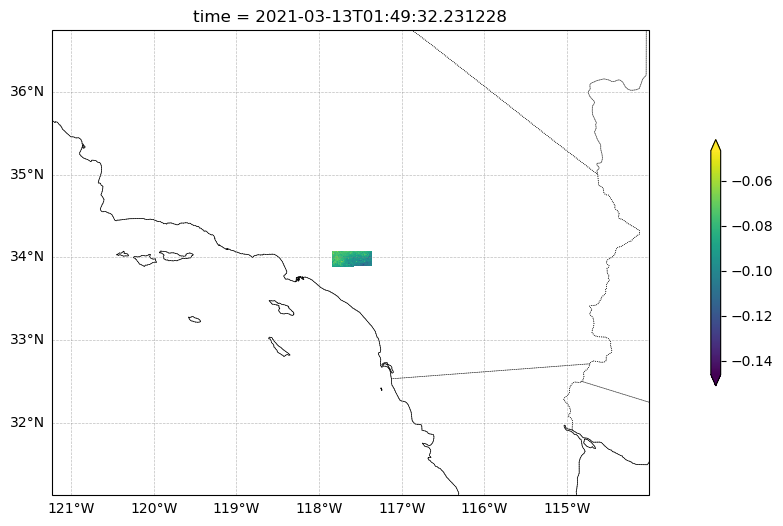

In [34]:
# plot the data on a map showing the location
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# 1. Plot the DataArray
# Assuming your xarray is named 'da' and has 'lat' and 'lon' dimensions
# transform=ccrs.PlateCarree() tells Cartopy the data's CRS
plot_obj = ts['displacement'].isel(time=10).plot(ax=ax, transform=data_crs, add_colorbar=False)
cbar = plt.colorbar(
    plot_obj, 
    ax=ax, 
    orientation='vertical', # Can be 'horizontal'
    shrink=0.4,             # Makes it shorter (percentage of axis)
    aspect=25,              # Makes it thinner (ratio of height/width)
    pad=0.08,               # Space between the map and the bar
    extend='both',           # Adds the "pointy" ends for data limits
    
)

# 2. Set the extent based on the array limits
buf = 300000
x_min, x_max = ts.x.min(), ts.x.max()
y_min, y_max = ts.y.min(), ts.y.max()
ax.set_extent([x_min-buf, x_max+buf, y_min-buf, y_max+buf], crs=data_crs)

# Add features
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5)

# Add Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False   # Turn off labels on top
gl.right_labels = False # Turn off labels on right
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER

# Plot data

plt.show()


In order to calculate delays for this time-series, we need to first extract the x/y/z locations of each pixel and then also extract the datetimes. 

In [47]:
# extract the x- and y- grids
import rioxarray
import numpy as np
import xarray as xr

x_grid, y_grid = np.meshgrid(ts.x, ts.y)

# 2. Convert these numpy arrays back into xarray DataArrays
# We copy the coordinates and attributes from the original 'da'
x_raster = xr.DataArray(x_grid, coords=ts.coords.drop_dims('time'), dims={'y': 700, 'x': 1500}, name="x_coords")
y_raster = xr.DataArray(y_grid, coords=ts.coords.drop_dims('time'), dims={'y': 700, 'x': 1500}, name="y_coords")

# 3. Export to GeoTIFF
# Ensure the CRS is defined
x_raster.rio.write_crs("EPSG:32611", inplace=True) 
y_raster.rio.write_crs("EPSG:32611", inplace=True)

x_raster.rio.to_raster("x_coordinates.tif")
y_raster.rio.to_raster("y_coordinates.tif")

## Weather model download

The first step in calculating the actual troposphere delays is to download Numerical weather prediction (NWP) model data from an online data repository. 
For this example we will use the High-resolution rapid refresh (HRRR) model generated by NOAA. 
RAiDER provides a Python API for accessing, downloading, and preprocessing the weather model data that will be used later to calculate delays. 

In [86]:
# extract the times
from datetime import datetime, timezone

dates = ts.time.dt.date
times = ts.time.dt.time # note that all the times are within ~1 minute or so
dt_naive = [datetime.combine(d, t) for d, t in zip(dates.values, times.values)]
dt_aware = [dtn.replace(tzinfo=timezone.utc) for dtn in dt_naive]

In [88]:
from RAiDER.models.hrrr import HRRR
from RAiDER.processWM import prepareWeatherModel

In [89]:
# loop through each datetime and download and preprocess the appropriate NWP model data
# note that this will create a new folder "weather_files" unless specified otherwise
# see docstring for prepareWeatherModel for more details
weather_model = HRRR()
ll_bounds = [33.5, 34.5, -118, -117] #SNWE
for date_time in dt_aware:
    prepareWeatherModel(weather_model, date_time, ll_bounds=ll_bounds, makePlots=False)

Weather model HRRR is available from 2016-07-15 00:00:00+00:00 to 2026-01-05 19:30:36.872375+00:00
Weather model HRRR is available from 2016-07-15 00:00:00+00:00 to 2026-01-05 19:30:36.872375+00:00
Rounded given datetime from  2021-01-06 01:50:15.552375+00:00 to 2021-01-06 02:00:00+00:00
✅ Found ┊ model=hrrr ┊ product=nat ┊ 2021-Jan-06 02:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/herbie/core.py:823: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


👨🏻‍🏭 Created directory: [/Users/jlmd9g/software/RAiDER-docs/notebooks/RAiDER_tutorial/weather_files/hrrr/20210106]


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.m

Number of weather model nodes: 156408
Shape of weather model: (56, 49, 57)
Bounds of the weather model: -384306.15/-219306.15/-1908520.14/-1764520.14 (SNWE)
Weather model: HRRR
Mean value of the wet refractivity: 14.137189
Mean value of the hydrostatic refractivity: 174.215698

======Weather Model class object=====
Weather model time: 2021-01-06 01:50:15.552375+00:00
Latitude resolution: 0.02702702702702703
Longitude resolution: 0.02702702702702703
Native projection: PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["unknown",ELLIPSOID["unknown",6371229,0,LENGTHUNIT["metre",1,ID["EPSG",9001]]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8901]]],CONVERSION["unknown",METHOD["Lambert Conic Conformal (2SP)",ID["EPSG",9802]],PARAMETER["Latitude of false origin",38.5,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8821]],PARAMETER["Longitude of false origin",262.5,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8822]],PARAMETER["Latitude of 1st standard parallel",38.

...

/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/herbie/core.py:823: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


👨🏻‍🏭 Created directory: [/Users/jlmd9g/software/RAiDER-docs/notebooks/RAiDER_tutorial/weather_files/hrrr/20210424]


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.m

ERROR: cannot rename 'gh' because it is not a variable or dimension in this dataset
Traceback (most recent call last):
  File "/Users/jlmd9g/software/RAiDER/tools/RAiDER/models/weatherModel.py", line 173, in fetch
    self._fetch(out)
  File "/Users/jlmd9g/software/RAiDER/tools/RAiDER/models/hrrr.py", line 281, in _fetch
    download_hrrr_file(bounds, corrected_DT, out, 'hrrr', self._model_level_type)
  File "/Users/jlmd9g/software/RAiDER/tools/RAiDER/models/hrrr.py", line 104, in download_hrrr_file
    ds_out = ds_out.rename({'gh': 'z', coord: 'levels'})
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/xarray/core/dataset.py", line 4239, in rename
    return self._rename(name_dict=name_dict, **names)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/xarray/core/dataset.py", line 4177, in _rename
    raise Valu

ValueError: cannot rename 'gh' because it is not a variable or dimension in this dataset

We can look at the files generated. 
These files are weather model files that have been processed to generate wet and hydrostatic refractivity on the native weather model grid.
We will interpolate from these grids to obtain the total delays at the actual pixel locations. 

The processed files have the datetime as well as the bounding box covered listed in the file name. 

In [93]:
# change this if you change the path to the weather files
!ls weather_files/HRRR_*N*.nc

weather_files/HRRR_2018_11_13_T00_00_00_36N_38N_77W_75W.nc
weather_files/HRRR_2018_11_13_T23_00_00_36N_38N_77W_75W.nc
weather_files/HRRR_2020_01_03_T00_00_00_24N_46N_124W_112W.nc
weather_files/HRRR_2020_01_03_T00_00_00_27N_40N_124W_111W.nc
weather_files/HRRR_2021_01_06_T01_50_15_33N_35N_119W_116W.nc
weather_files/HRRR_2021_01_12_T01_49_33_33N_35N_119W_116W.nc
weather_files/HRRR_2021_01_24_T01_49_33_33N_35N_119W_116W.nc
weather_files/HRRR_2021_01_30_T01_50_14_33N_35N_119W_116W.nc
weather_files/HRRR_2021_02_05_T01_49_32_33N_35N_119W_116W.nc
weather_files/HRRR_2021_02_11_T01_50_14_33N_35N_119W_116W.nc
weather_files/HRRR_2021_02_17_T01_49_32_33N_35N_119W_116W.nc
weather_files/HRRR_2021_02_23_T01_50_14_33N_35N_119W_116W.nc
weather_files/HRRR_2021_03_01_T01_49_32_33N_35N_119W_116W.nc
weather_files/HRRR_2021_03_07_T01_50_14_33N_35N_119W_116W.nc
weather_files/HRRR_2021_03_13_T01_49_32_33N_35N_119W_116W.nc
weather_files/HRRR_2021_03_19_T01_50_14_33N_35N_119W_116W.nc
weather_files/HRRR_2021_03_2

## Delay calculation

In [94]:
from RAiDER.delay import tropo_delay

RAiDER has a number of options for calculating delays. 
In this case, we want to pass the x/y pixel locations as raster files that RAiDER will use. RAiDER will first download a DEM to obtain height values, then use 3D interpolation to intersect the DEM with the 3D grid of ZTD available in the processed weather model NetCDF files. 

In [97]:
# we need to load the x/y rasters we created earlier
from RAiDER.llreader import RasterRDR

In [98]:
?RasterRDR

Init signature:
RasterRDR(
    lat_file,
    lon_file=None,
    *,
    hgt_file=None,
    dem_file=None,
    convention='isce',
    cube_spacing_in_m: Optional[float] = None,
    output_directory='/Users/jlmd9g/software/RAiDER-docs/notebooks/RAiDER_tutorial',
) -> None
Docstring:      Use a 2-band raster file containing lat/lon coordinates.
File:           ~/software/RAiDER/tools/RAiDER/llreader.py
Type:           type
Subclasses:     

In [99]:
query_points = RasterRDR('x_coordinates.tif', 'y_coordinates.tif')

We can view information about the query points object by printing the object and by using the built-in methods. 

In [100]:
query_points

AOI: RasterRDR((421995.0, 466965.0, 3750165.0, 3771135.0), radar_rasters)

In [103]:
query_points.projection()

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]')

In addition to the x/y locations, we need elevation data. 
The `AOI` object has built-in functionality to download a DEM if heights are not provided. 

In [105]:
query_points.readZ()

Incorrect4326Bounds: Make sure bounds have intersection over standard 4326 CRS i.e. between longitude -180 and 180 and latitude -90 and 90.

### Other parameters for `tropo_delay`

The `tropo_delay` function takes several parameters, which we can view by looking at the docstring for the function. 
In particular, in addition to the `AOI` object we have already defined, we will need an `LOS` object to define the look direction and projection information. 

In [95]:
help(tropo_delay)

Help on function tropo_delay in module RAiDER.delay:

tropo_delay(datetime: datetime.datetime, weather_model_file: str, aoi: RAiDER.llreader.AOI, los: RAiDER.losreader.LOS, height_levels: Optional[list[float]] = None, out_proj: Union[int, str] = 4326, zref: Optional[numpy.float64] = None)
    Calculate integrated delays on query points.

    Options are:
    1. Zenith delays (ZTD)
    2. Zenith delays projected to the line-of-sight (STD-projected)
    3. Slant delays integrated along the raypath (STD-raytracing)

    Args:
        datetime: Datetime          - Datetime object for determining when to calculate delays
        weather_model_File: string  - Name of the NETCDF file containing a pre-processed weather model
        aoi: AOI object             - AOI object
        los: LOS object             - LOS object
        height_levels: list         - (optional) list of height levels on which to calculate delays. Only needed for cube generation.
        out_proj: int,str           - (op

In [107]:
# RAiDER can handle ZTD, projected slant delays, or raytracing slant delays
# Raytracing requires an orbit file, so we will use the conventional slant delay
from RAiDER.losreader import Zenith, Conventional, Raytracing

In [108]:
los = Conventional()

In [109]:
?Conventional

Init signature: Conventional(filename=None, los_convention='isce', time=None, pad=600) -> None
Docstring:     
Special value indicating that the zenith delay will
be projected using the standard cos(inc) scaling.
File:           ~/software/RAiDER/tools/RAiDER/losreader.py
Type:           ABCMeta
Subclasses:     

In [ ]:
# statevectors
#  return t, x, y, z, vx, vy, vz 